Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading cleaned data...
Taxi trips: 5,282,871
Bike trips: 3,482,918
MTA hourly entries: 596,220
Loaded bike mapping: 1873 stations
Loaded MTA mapping: 428 stations
Bike trips mapped to zones: 3,482,825
MTA entries mapped to zones: 596,220
Total unique zones: 255
Zone demand matrix shape: (5664, 255) (time steps × zones)
Adjacency matrix shape: (255, 255)
Train: torch.Size([4231, 12, 255, 1]), Val: torch.Size([746, 12, 255, 1]), Test: torch.Size([657, 12, 255, 1])
Model parameters: 593,729
Training multimodal DCRNN...
Epoch  5/50 | Train Loss: 0.00249 | Val Loss: 0.00361 | Sampling: 0.875
Epoch 10/50 | Train Loss: 0.00261 | Val Loss: 0.00388 | Sampling: 0.750
Epoch 15/50 | Train Loss: 0.00251 | Val Loss: 0.00340 | Sampling: 0.625
Epoch 20/50 | Train Loss: 0.00257 | Val Loss: 0.00418 | Sampling: 0.500
Epoch 25/50 | Train Loss: 0.00261 | Val Loss: 0.00313 | Samp

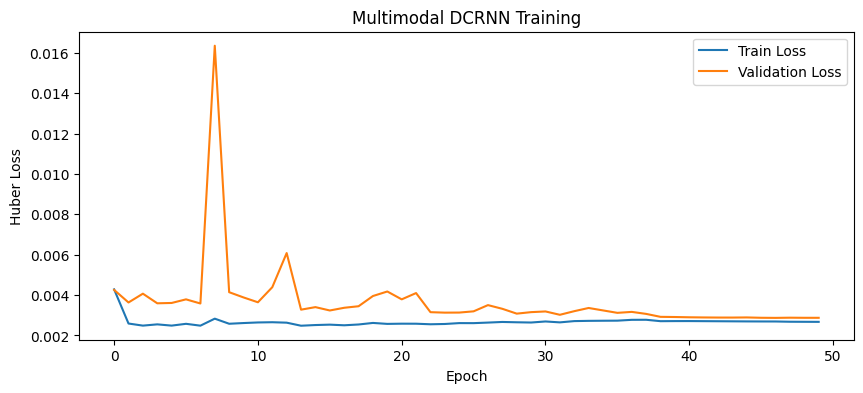


Multimodal DCRNN Test Performance (city-level total demand)
15min | MAE: 3239.57 | RMSE: 5574.54 | MAPE: 14.67%
30min | MAE: 3994.21 | RMSE: 6479.87 | MAPE: 18.10%
45min | MAE: 4515.24 | RMSE: 6902.41 | MAPE: 20.38%
1h    | MAE: 5505.68 | RMSE: 7908.45 | MAPE: 24.92%

Average per-zone MAE (1-step): 17.05 trips per 15-min bin


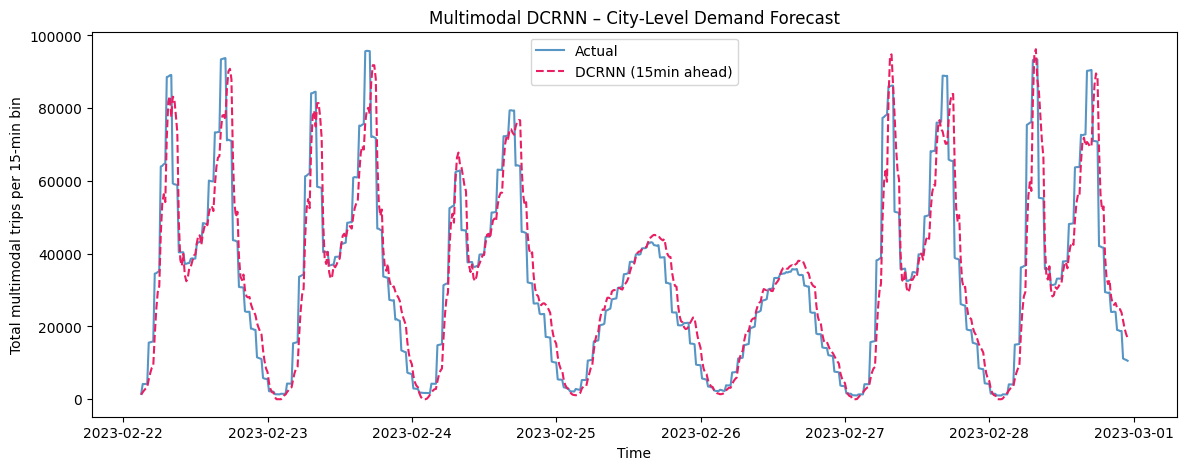


✅ Multimodal DCRNN evaluation completed. Results saved.


In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import geopandas as gpd
from libpysal.weights import Queen
import urllib.request
import zipfile
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE = Path("/content/drive/MyDrive")
PROCESSED = DRIVE
MAPPING_DIR = Path("/content/drive/MyDrive")

# Create mapping directory if it doesn't exist (for saving/loading)
MAPPING_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Load cleaned data and mapping dictionaries
# ------------------------------------------------------------------------------
print("Loading cleaned data...")
df_taxi = pd.read_parquet(DRIVE / "taxi_clean_2023_all_months.parquet")
df_taxi["time_bin"] = pd.to_datetime(df_taxi["time_bin"])
print(f"Taxi trips: {len(df_taxi):,}")

df_bike = pd.read_parquet(DRIVE / "bike_clean_2023.parquet")
df_bike["time_bin"] = pd.to_datetime(df_bike["time_bin"])
print(f"Bike trips: {len(df_bike):,}")

df_mta = pd.read_parquet(DRIVE / "mta_clean_2023.parquet")
df_mta["time_bin"] = pd.to_datetime(df_mta["time_bin"])
print(f"MTA hourly entries: {len(df_mta):,}")

# Load station‑to‑zone mappings
bike_station_to_zone = joblib.load(MAPPING_DIR / "bike_station_to_zone.pkl")
mta_station_to_zone = joblib.load(MAPPING_DIR / "mta_station_to_zone.pkl")
print(f"Loaded bike mapping: {len(bike_station_to_zone)} stations")
print(f"Loaded MTA mapping: {len(mta_station_to_zone)} stations")

# ------------------------------------------------------------------------------
# 2. Map bike and MTA to taxi zones
# ------------------------------------------------------------------------------
df_bike["zone_id"] = df_bike["start_station_id"].astype(str).map(bike_station_to_zone)
df_bike = df_bike.dropna(subset=["zone_id"])
df_bike["zone_id"] = df_bike["zone_id"].astype(int)
print(f"Bike trips mapped to zones: {len(df_bike):,}")

df_mta["zone_id"] = df_mta["station_complex_id"].astype(str).map(mta_station_to_zone)
df_mta = df_mta.dropna(subset=["zone_id"])
df_mta["zone_id"] = df_mta["zone_id"].astype(int)
print(f"MTA entries mapped to zones: {len(df_mta):,}")

# ------------------------------------------------------------------------------
# 3. Aggregate each mode into zone × 15‑min matrices
# ------------------------------------------------------------------------------
# Taxi
taxi_agg = df_taxi.groupby(["time_bin", "PULocationID"]).size().reset_index(name="taxi")
taxi_agg.rename(columns={"PULocationID": "zone_id"}, inplace=True)

# Bike
bike_agg = df_bike.groupby(["time_bin", "zone_id"]).size().reset_index(name="bike")

# MTA (hourly → spread to 15‑min)
mta_hourly = df_mta.groupby(["time_bin", "zone_id"])["entries"].sum().reset_index()
mta_hourly["time_bin"] = pd.to_datetime(mta_hourly["time_bin"])
mta_15min = []
for _, row in mta_hourly.iterrows():
    hour_start = row["time_bin"]
    zone = row["zone_id"]
    entries = row["entries"]
    demand_15min = entries / 4.0
    for offset in [0, 15, 30, 45]:
        bin_time = hour_start + pd.Timedelta(minutes=offset)
        mta_15min.append({"time_bin": bin_time, "zone_id": zone, "mta": demand_15min})
mta_agg = pd.DataFrame(mta_15min)

# ------------------------------------------------------------------------------
# 4. Combine all modes into one zone‑demand matrix (total multimodal)
# ------------------------------------------------------------------------------
# Determine full time index
time_min = min(taxi_agg["time_bin"].min(), bike_agg["time_bin"].min(), mta_agg["time_bin"].min())
time_max = max(taxi_agg["time_bin"].max(), bike_agg["time_bin"].max(), mta_agg["time_bin"].max())
full_time = pd.date_range(start=time_min, end=time_max, freq="15min")

# All zones that appear in any mode
all_zones = sorted(set(taxi_agg["zone_id"]) | set(bike_agg["zone_id"]) | set(mta_agg["zone_id"]))
print(f"Total unique zones: {len(all_zones)}")

# Pivot each mode
taxi_pivot = taxi_agg.pivot(index="time_bin", columns="zone_id", values="taxi").fillna(0)
bike_pivot = bike_agg.pivot(index="time_bin", columns="zone_id", values="bike").fillna(0)
mta_pivot = mta_agg.pivot(index="time_bin", columns="zone_id", values="mta").fillna(0)

# Reindex to full time and all zones
taxi_pivot = taxi_pivot.reindex(index=full_time, columns=all_zones, fill_value=0)
bike_pivot = bike_pivot.reindex(index=full_time, columns=all_zones, fill_value=0)
mta_pivot = mta_pivot.reindex(index=full_time, columns=all_zones, fill_value=0)

# Sum to get total multimodal demand per zone per 15‑min
zone_demand = taxi_pivot + bike_pivot + mta_pivot
zone_demand = zone_demand.astype(np.float32)
print(f"Zone demand matrix shape: {zone_demand.shape} (time steps × zones)")

# ------------------------------------------------------------------------------
# 5. Load shapefile and build spatial adjacency (Queen contiguity)
# ------------------------------------------------------------------------------
zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
zones_dir = Path("/content/data/raw/taxi_zones")
zones_dir.mkdir(parents=True, exist_ok=True)
zip_path = zones_dir / "taxi_zones.zip"
shp_path = zones_dir / "taxi_zones" / "taxi_zones.shp"

if not shp_path.exists():
    print("Downloading shapefile...")
    urllib.request.urlretrieve(zones_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(zones_dir)

zones_gdf = gpd.read_file(shp_path)
zones_gdf = zones_gdf.rename(columns={"LocationID": "zone_id"})
# Keep only zones present in our data
zones_gdf = zones_gdf[zones_gdf["zone_id"].isin(all_zones)]
zones_gdf = zones_gdf.set_index("zone_id").sort_index()

# Build Queen contiguity
weights = Queen.from_dataframe(zones_gdf, ids=zones_gdf.index)
adj = weights.full()[0].astype(np.float32)
print(f"Adjacency matrix shape: {adj.shape}")

# Build diffusion matrices (row-normalised, undirected)
def build_diffusion_matrices(adj):
    d = adj.sum(axis=1, keepdims=True)
    d_inv = np.where(d > 0, 1.0 / d, 0.0)
    P_f = d_inv * adj
    P_b = P_f.copy()
    return torch.FloatTensor(P_f), torch.FloatTensor(P_b)

P_f, P_b = build_diffusion_matrices(adj)
N = adj.shape[0]

# ------------------------------------------------------------------------------
# 6. Prepare sequences (train/val/test split, scaling)
# ------------------------------------------------------------------------------
LOOKBACK = 12      # 3 hours input (15‑min steps)
HORIZON = 4        # 1 hour forecast (4 steps)
TEST_STEPS = 672   # last 7 days for testing

mat = zone_demand.values.astype(np.float32)
train_mat = mat[:-TEST_STEPS]
test_mat = mat[-TEST_STEPS:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_mat)
test_scaled = scaler.transform(test_mat)

def make_sequences(mat, lookback, horizon):
    X, y = [], []
    for i in range(lookback, len(mat) - horizon + 1):
        X.append(mat[i-lookback:i, :, np.newaxis])   # [T, N, 1]
        y.append(mat[i:i+horizon, :, np.newaxis])    # [H, N, 1]
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(train_scaled, LOOKBACK, HORIZON)
val_size = int(len(X_all) * 0.15)
X_tr = torch.FloatTensor(X_all[:-val_size])
y_tr = torch.FloatTensor(y_all[:-val_size])
X_val = torch.FloatTensor(X_all[-val_size:])
y_val = torch.FloatTensor(y_all[-val_size:])
X_te, y_te = make_sequences(test_scaled, LOOKBACK, HORIZON)
X_te = torch.FloatTensor(X_te)
y_te = torch.FloatTensor(y_te)

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_te.shape}")

# ------------------------------------------------------------------------------
# 7. DCRNN Model (full, unchanged)
# ------------------------------------------------------------------------------
class DiffusionConv(nn.Module):
    def __init__(self, in_features, out_features, K=3):
        super().__init__()
        self.K = K
        self.linear = nn.Linear((2 * (K + 1)) * in_features, out_features, bias=True)

    def forward(self, x, P_f, P_b):
        batch, N, F = x.shape
        diffusions = []
        for P in [P_f, P_b]:
            Pk = torch.eye(N, device=x.device)
            for k in range(self.K + 1):
                diffused = torch.einsum("nm,bmf->bnf", Pk, x)
                diffusions.append(diffused)
                Pk = Pk @ P
        out = torch.cat(diffusions, dim=-1)
        return self.linear(out)

class DCGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, K=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        concat_dim = input_dim + hidden_dim
        self.gate_r = DiffusionConv(concat_dim, hidden_dim, K)
        self.gate_u = DiffusionConv(concat_dim, hidden_dim, K)
        self.gate_c = DiffusionConv(concat_dim, hidden_dim, K)

    def forward(self, x, h, P_f, P_b):
        xh = torch.cat([x, h], dim=-1)
        r = torch.sigmoid(self.gate_r(xh, P_f, P_b))
        u = torch.sigmoid(self.gate_u(xh, P_f, P_b))
        xrh = torch.cat([x, r * h], dim=-1)
        c = torch.tanh(self.gate_c(xrh, P_f, P_b))
        h_next = u * h + (1 - u) * c
        return h_next

    def init_hidden(self, batch_size, N, device):
        return torch.zeros(batch_size, N, self.hidden_dim, device=device)

class DCRNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2, K=3):
        super().__init__()
        self.num_layers = num_layers
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            in_d = input_dim if i == 0 else hidden_dim
            self.cells.append(DCGRUCell(in_d, hidden_dim, K))

    def forward(self, x_seq, P_f, P_b):
        batch, T, N, _ = x_seq.shape
        device = x_seq.device
        hidden = [cell.init_hidden(batch, N, device) for cell in self.cells]
        for t in range(T):
            x_t = x_seq[:, t, :, :]
            for i, cell in enumerate(self.cells):
                hidden[i] = cell(x_t, hidden[i], P_f, P_b)
                x_t = hidden[i]
        return hidden

class DCRNNDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, num_layers=2, K=3):
        super().__init__()
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            in_d = output_dim if i == 0 else hidden_dim
            self.cells.append(DCGRUCell(in_d, hidden_dim, K))
        self.output_proj = nn.Linear(hidden_dim, output_dim)

    def forward(self, go_symbol, hidden, P_f, P_b, target_seq=None, training=True, sampling_ratio=0.5):
        batch, N, _ = go_symbol.shape
        horizon = target_seq.shape[1] if target_seq is not None else 12
        outputs = []
        x_t = go_symbol
        for t in range(horizon):
            new_hidden = []
            for i, cell in enumerate(self.cells):
                h_next = cell(x_t, hidden[i], P_f, P_b)
                new_hidden.append(h_next)
                x_t = h_next
            hidden = new_hidden
            pred = self.output_proj(x_t)
            outputs.append(pred)
            if training and target_seq is not None:
                use_gt = torch.rand(1).item() < sampling_ratio
                x_t = target_seq[:, t, :, :] if use_gt else pred.detach()
            else:
                x_t = pred.detach()
        return torch.stack(outputs, dim=1)

class DCRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, K=3, horizon=12):
        super().__init__()
        self.horizon = horizon
        self.encoder = DCRNNEncoder(input_dim, hidden_dim, num_layers, K)
        self.decoder = DCRNNDecoder(output_dim, hidden_dim, num_layers, K)

    def forward(self, x_seq, P_f, P_b, target_seq=None, training=True, sampling_ratio=0.5):
        hidden = self.encoder(x_seq, P_f, P_b)
        batch, _, N, _ = x_seq.shape
        go_symbol = torch.zeros(batch, N, self.decoder.output_dim, device=x_seq.device)
        preds = self.decoder(go_symbol, hidden, P_f, P_b, target_seq, training, sampling_ratio)
        return preds

# ------------------------------------------------------------------------------
# 8. Training setup
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
P_f, P_b = P_f.to(device), P_b.to(device)

config = {
    "input_dim": 1,
    "hidden_dim": 64,
    "output_dim": 1,
    "num_layers": 2,
    "K": 3,
    "horizon": HORIZON
}
model = DCRNN(**config).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
loss_fn = nn.HuberLoss(delta=1.0)

batch_size = 16
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

EPOCHS = 50
total_batches = len(train_loader) * EPOCHS
decay_steps = int(0.8 * total_batches)
def get_sampling_ratio(step):
    return max(0.0, 1.0 - step / decay_steps) if step < decay_steps else 0.0

best_val_loss = float('inf')
patience = 10
patience_counter = 0
best_state = None
global_step = 0
train_losses, val_losses = [], []

print("Training multimodal DCRNN...")
for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        ratio = get_sampling_ratio(global_step)
        optimizer.zero_grad()
        pred = model(Xb, P_f, P_b, target_seq=yb, training=True, sampling_ratio=ratio)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        epoch_loss += loss.item()
        global_step += 1
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb, P_f, P_b, target_seq=yb, training=False)
            val_loss += loss_fn(pred, yb).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {avg_train:.5f} | Val Loss: {avg_val:.5f} | Sampling: {get_sampling_ratio(global_step):.3f}")

model.load_state_dict(best_state)
torch.save(model.state_dict(), "/content/dcrnn_multimodal_best.pt")
print("Training completed. Best model saved.")

# Plot training curve
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Multimodal DCRNN Training')
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# 9. Evaluation
# ------------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    pred_scaled = model(X_te.to(device), P_f, P_b, training=False).cpu().numpy()
y_te_np = y_te.numpy()

def inverse_scale_2d(scaler, data_2d):
    """data_2d: (samples, features) -> inverse transform, same shape"""
    return scaler.inverse_transform(data_2d)

print("\n" + "="*60)
print("Multimodal DCRNN Test Performance (city-level total demand)")
print("="*60)
for h in range(HORIZON):
    pred_h = pred_scaled[:, h, :, 0]   # (test_samples, N)
    true_h = y_te_np[:, h, :, 0]       # (test_samples, N)
    pred_h_inv = inverse_scale_2d(scaler, pred_h)
    true_h_inv = inverse_scale_2d(scaler, true_h)
    pred_total = np.maximum(pred_h_inv.sum(axis=1), 0)
    true_total = true_h_inv.sum(axis=1)
    mae = np.mean(np.abs(true_total - pred_total))
    rmse = np.sqrt(np.mean((true_total - pred_total)**2))
    mape = np.mean(np.abs((true_total - pred_total) / (true_total + 1e-5))) * 100
    label = ["15min", "30min", "45min", "1h"][h]
    print(f"{label:5s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

# Per-zone MAE at 1-step
pred_1 = pred_scaled[:, 0, :, 0]
true_1 = y_te_np[:, 0, :, 0]
pred_1_inv = inverse_scale_2d(scaler, pred_1)
true_1_inv = inverse_scale_2d(scaler, true_1)
zone_mae = np.mean(np.abs(true_1_inv - pred_1_inv), axis=0)
avg_zone_mae = np.mean(zone_mae)
print(f"\nAverage per-zone MAE (1-step): {avg_zone_mae:.2f} trips per 15-min bin")

# Save results
pd.DataFrame([{
    "model": "Multimodal DCRNN (taxi+bike+MTA)",
    "MAE_city_1h": mae,   # last horizon's MAE (1h)
    "RMSE_city_1h": rmse,
    "MAPE_city_1h": mape,
    "avg_zone_MAE_15min": avg_zone_mae
}]).to_csv("/content/dcrnn_multimodal_results.csv", index=False)

# Plot city-level forecast (1-step ahead)
test_time_bins = zone_demand.index[-TEST_STEPS + LOOKBACK : -TEST_STEPS + LOOKBACK + len(pred_total)]
plt.figure(figsize=(14,5))
plt.plot(test_time_bins, true_total, label='Actual', color='#2C7BB6', alpha=0.8)
plt.plot(test_time_bins, pred_total, label='DCRNN (15min ahead)', color='#E91E63', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Total multimodal trips per 15-min bin')
plt.title('Multimodal DCRNN – City‑Level Demand Forecast')
plt.legend()
plt.show()

print("\n✅ Multimodal DCRNN evaluation completed. Results saved.")

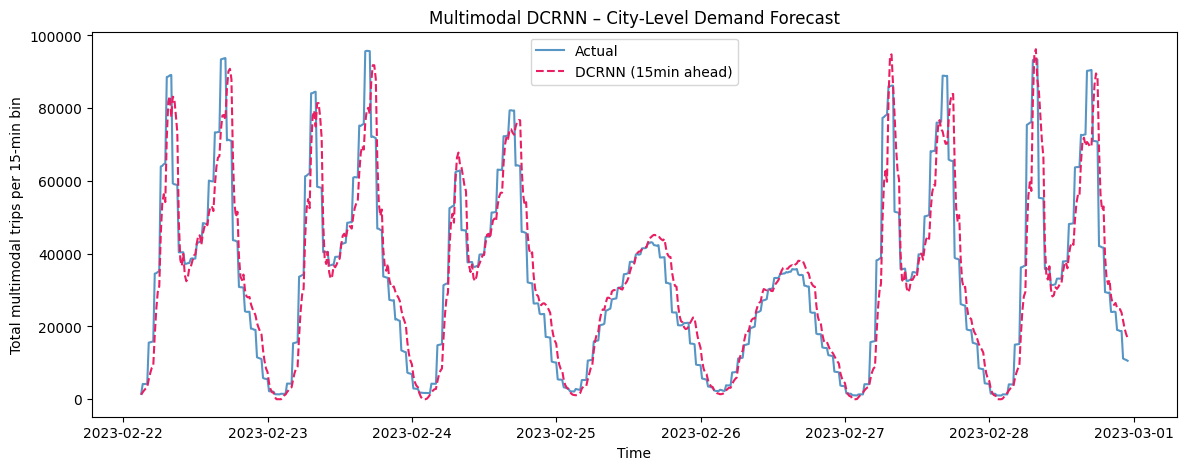

In [ ]:
# Correct the time axis for the plot
start_date = zone_demand.index[-TEST_STEPS + LOOKBACK]
test_time_bins = pd.date_range(start=start_date, periods=len(pred_total), freq='15min')

plt.figure(figsize=(14,5))
plt.plot(test_time_bins, true_total, label='Actual', color='#2C7BB6', alpha=0.8)
plt.plot(test_time_bins, pred_total, label='DCRNN (15min ahead)', color='#E91E63', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Total multimodal trips per 15-min bin')
plt.title('Multimodal DCRNN – City‑Level Demand Forecast')
plt.legend()
plt.show()